before: 15.786162 
 after: 30.020348


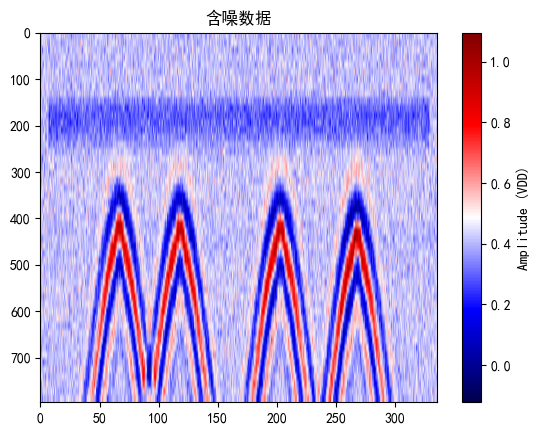

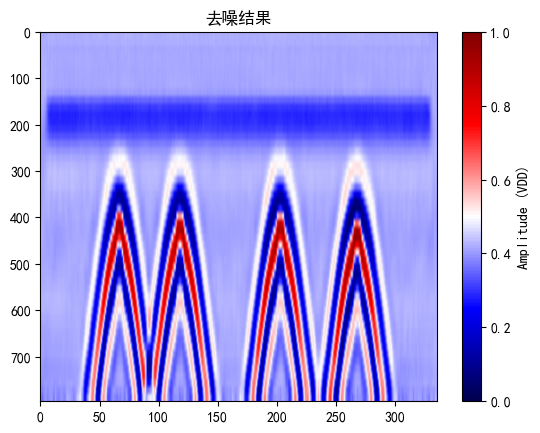

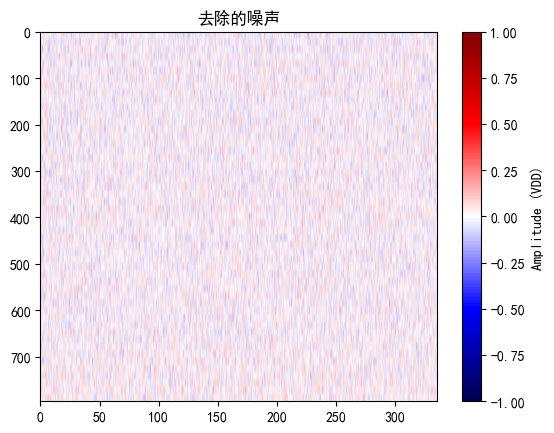

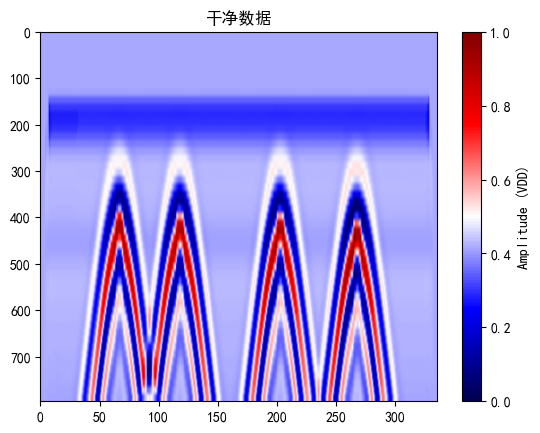

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib import rcParams
# from U_Net import UNet 
from UNet_3Plus import UNet_3Plus_DeepSup  # 请确保你的模型类是正确导入的
from U_Net_CBAM import UNet

rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

# ==========================
# 只需要改这里的文件名前缀
# ==========================
prefix = "sta_f0_D"

# 基础路径
base_dir = r"D:\桌面\项目\shandong"
data_dir = os.path.join(base_dir, "数据")
model_dir = os.path.join(base_dir, "CU_Net_828")

# 模型加载
model = UNet()
model_path = os.path.join(model_dir, "model_epoch_400.pth")
model.load_state_dict(torch.load(model_path, weights_only=True))

# 数据加载
clean = np.load(os.path.join(data_dir, f"{prefix}.npy"))
noisy = np.load(os.path.join(data_dir, f"{prefix}_noised.npy"))

clean = torch.tensor(clean, dtype=torch.float32)
noisy = torch.tensor(noisy, dtype=torch.float32)
input = noisy.unsqueeze(0).unsqueeze(0)

# 计算SNR
def calculate_snr(predictions, targets):
    noise = predictions - targets
    signal_power = np.mean(targets**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

# 预测
model.eval()
with torch.no_grad():
    prediction = model(input)
    prediction, *_ = prediction  # 解包元组，取第一个元素

    initial = input.squeeze(0).squeeze(0).numpy()
    pure = clean.squeeze(0).numpy()
    result = prediction.squeeze(0).squeeze(0).numpy()
    noise = initial - result
    res = initial - result

    # SNR
    snr_noised = calculate_snr(initial, pure)
    snr_denoised = calculate_snr(result, pure)
    print("before:", snr_noised, "\n", "after:", snr_denoised)

    # 保存结果，名字自动跟 prefix 走
    np.save(os.path.join(data_dir, f"{prefix}_result.npy"), result)
    np.save(os.path.join(data_dir, f"{prefix}_noise.npy"), noise)

    # 绘图
    plt.figure()
    plt.title('含噪数据')
    plt.imshow(noisy, aspect='auto', cmap='seismic', extent=(0, 336, 796, 0))
    plt.colorbar(label='Amplitude (VDD)')

    plt.figure()
    plt.title('去噪结果')
    plt.imshow(result, aspect='auto', cmap='seismic', extent=(0, 336, 796, 0))
    plt.clim(0, 1)
    plt.colorbar(label='Amplitude (VDD)')

    plt.figure()
    plt.title('去除的噪声')
    plt.imshow(res, aspect='auto', cmap='seismic', extent=(0, 336, 796, 0))
    plt.clim(-1, 1)
    plt.colorbar(label='Amplitude (VDD)')

    plt.figure()
    plt.title('干净数据')
    plt.imshow(pure, aspect='auto', cmap='seismic', extent=(0, 336, 796, 0))
    plt.colorbar(label='Amplitude (VDD)')

    plt.show()


(1200, 361)


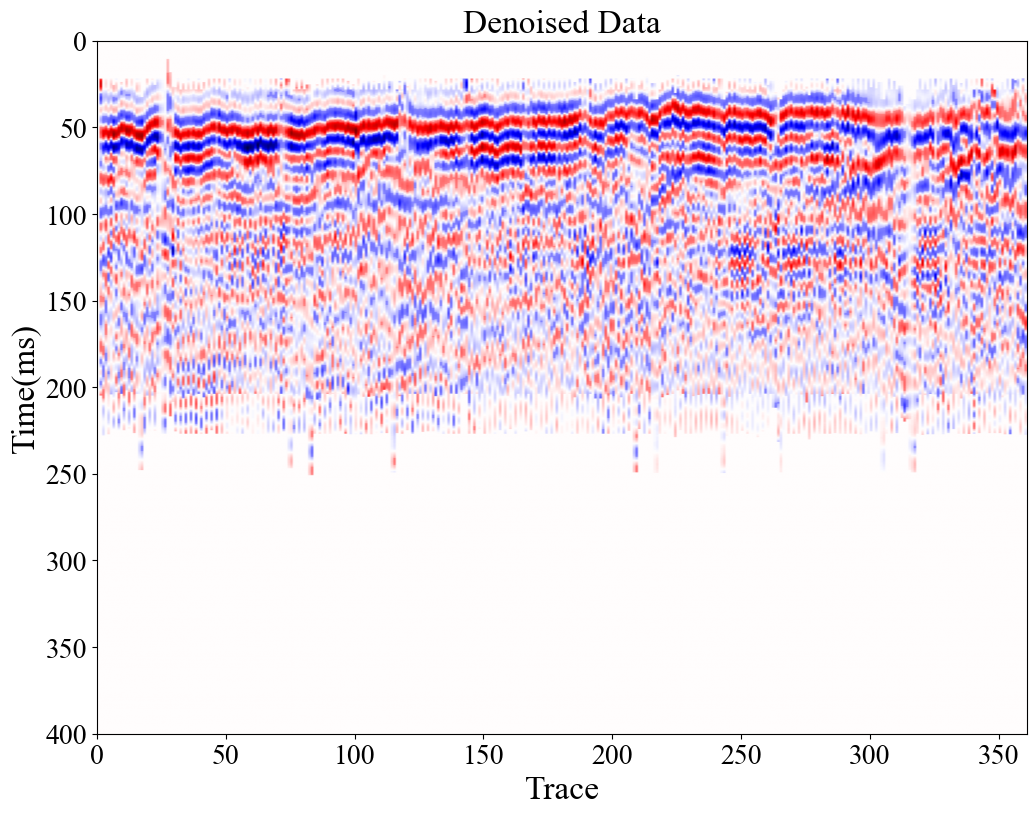

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from U_Net import UNet 
from matplotlib import rcParams
from UNet_3Plus import UNet_3Plus_DeepSup  # 请确保你的模型类是正确导入的
import scipy.signal as signal
rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

# 读取 .npy 文件
data = np.load(r'D:\桌面\随机噪声压制\shandong\数据\yxsn5cdpn.npy')
print(data.shape)  # 输出数据形状

plt.figure(figsize=(12, 9))
plt.title('Denoised Data', fontsize=24, family='Times New Roman')
plt.imshow(data, aspect='auto', cmap='seismic', extent=(0, 361, 400, 0))
plt.clim(0, 1)
# plt.colorbar()
plt.ylabel('Time(ms)', fontsize=24, family='Times New Roman')
plt.xlabel('Trace',  fontsize=24, family='Times New Roman')
plt.xticks(fontsize=20, fontname='Times New Roman')
plt.yticks(fontsize=20, fontname='Times New Roman')
# plt.savefig(r'D:\桌面\随机噪声压制\shandong\图片\yxsn5cdpn_denoised_(0-1)', dpi=600, bbox_inches='tight')
plt.show()  

